In [1]:
import numpy as np
import pickle
from matplotlib import pyplot as plt

from qiskit import transpile
from qiskit_ibm_runtime import QiskitRuntimeService


from qiskit.circuit import Parameter, ParameterVector

from hubo_qaoa.utils.parameterise_circuit import parameterise_circuit
from hubo_qaoa.utils.lr_qaoa import get_LR_qaoa_circuit, get_hardware_LR_qaoa_circuit



In [2]:
filename_to_copy_numbers = {
    'test_N4_W6': [2,2,1,1]
}

In [3]:
service = QiskitRuntimeService(name='us_instance')
backend = service.backend(name='ibm_boston')

In [4]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingall.precompute.0.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)



In [5]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingheavy-hex.precompute.60.pkl'
with open(data_file, 'rb') as f:
    res_hardware = pickle.load(f)

In [6]:
delta_b, delta_g = 0.75, 0.30
p = 1

In [42]:
depths_abstract = []
counts_abstract = []
widths = []
for filename in res.keys():
    cost_circuit = res[filename]['rzz']['circuit']
    num_qubits = cost_circuit.num_qubits
    phis = ParameterVector('ϕ', num_qubits)
    try:
        fixed_qc, circuit = get_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, None, phis, True)
        
        widths.append(num_qubits)
        depths_abstract.append(fixed_qc.depth(lambda instr: len(instr.qubits) > 1))
        counts_abstract.append(sum([v for k, v in fixed_qc.count_ops().items() if k in ['rzz', 'cz', 'cx']]))
    except:
        pass
widths = np.array(widths)    
depths_abstract = np.array(depths_abstract)    
counts_abstract = np.array(counts_abstract)    


15:59:04 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 16


INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 16


15:59:04 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 145


INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 145


15:59:04 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 173


...

INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 628


15:59:04 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 821


INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 821


15:59:04 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 900


INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 900


In [ ]:
widths_hardware = []
depths_hardware = []
counts_hardware = []
for filename in res_hardware.keys():
    cost_circuit = res_hardware[filename]['rzz']['circuit']
    try:
        num_qubits = res[filename]['rzz']['circuit'].num_qubits
    except:
        from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
        filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
        _, n, _, T = gfa_file_to_graph(filepath, filename_to_copy_numbers[filename])
        print(filename, n, T)
        num_qubits: int = n*T
        
    phis = ParameterVector('ϕ', num_qubits)
    layout = res_hardware[filename]['rzz']['layout']
    try:
        fixed_qc, _, _ = get_hardware_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, layout, backend, None, phis)    
        widths_hardware.append(num_qubits)
        depths_hardware.append(fixed_qc.depth(lambda instr: len(instr.qubits) > 1))
        counts_hardware.append(sum([v for k, v in fixed_qc.count_ops().items() if k in ['rzz', 'cz', 'cx']]))
    except Exception as e:
        print(e)
widths_hardware = np.array(widths_hardware)    
depths_hardware = np.array(depths_hardware)    
counts_hardware = np.array(counts_hardware)     

15:59:05 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 106


INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 106


15:59:06 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1011


INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 1011


15:59:07 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 1039


...

INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 7125


15:59:38 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 8297


INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 8297


15:59:44 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 9400


INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 9400


In [44]:
indices = np.argsort(widths)
print('filename qubits depths count')
for index in indices:
    print(np.array(list(res.keys()))[index], widths[index], depths_abstract[index], counts_abstract[index])

filename qubits depths count
test_N2_W2 4 12 11
test_N7_W2 8 393 475
test_N8_W2 8 388 460
trivial 9 140 186
test_N7_W3 12 766 1037
test_N3_W4 12 168 302
test_N8_W3 12 690 889
test_N4_W5 15 195 405
test_N8_W4 16 623 1176
test_N7_W4 16 845 1574
test_N4_W6 18 207 521
test_N7_W5 20 1122 2538
test_N8_W5 20 816 1968
test_N8_W6 24 895 2381


In [45]:
indices = np.argsort(widths_hardware)
print('filename qubits depths count')
for index in indices:
    print(np.array(list(res_hardware.keys()))[index], widths_hardware[index], depths_hardware[index], counts_hardware[index])

filename qubits depths count
test_N2_W2 4 23 28
test_N7_W2 8 1398 2015
test_N8_W2 8 1251 1864
trivial 9 305 533
test_N7_W3 12 2794 4697
test_N3_W4 12 299 700
test_N8_W3 12 2444 4057
test_N4_W5 15 931 1691
test_N8_W4 16 2854 5265
test_N7_W4 16 4570 8663
test_N4_W6 18 848 1695
test_N7_W5 20 5575 12571
test_N8_W5 20 3282 7758


In [46]:
grid = np.linspace(min(widths[0], widths_hardware[0]), max(widths[-1], widths_hardware[-1]), 100)
p_depth = np.polynomial.Polynomial.fit(widths, depths_abstract, 1)
p_depth_hardware = np.polynomial.Polynomial.fit(widths_hardware, depths_hardware, 1)
p_count = np.polynomial.Polynomial.fit(widths, counts_abstract, 2)
p_count_hardware = np.polynomial.Polynomial.fit(widths_hardware, counts_hardware, 2)


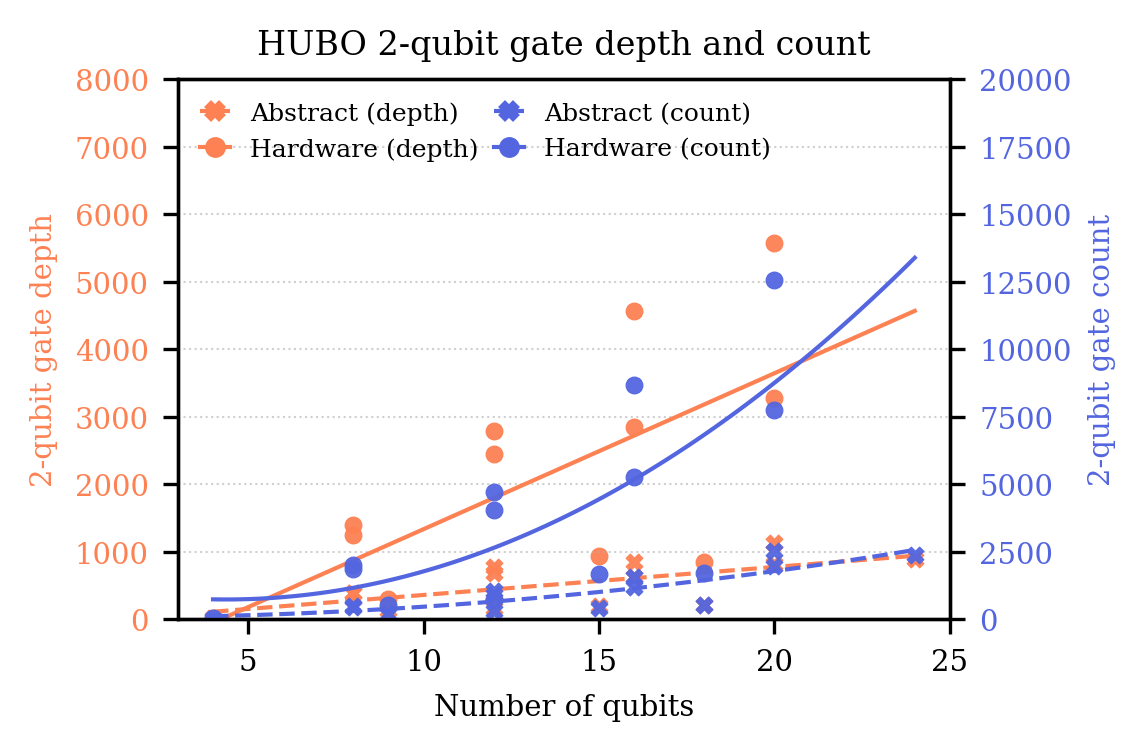

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator, MaxNLocator

# --- helper for rounding y-axis nicely (keep your existing function if preferred) ---
def nice_upper_limit(data, n_ticks=6):
    max_val = np.max(data)
    raw_step = max_val / (n_ticks - 1)
    magnitude = 10 ** np.floor(np.log10(raw_step))
    residual = raw_step / magnitude
    if residual < 1.5:
        nice_step = 1 * magnitude
    elif residual < 2.6:
        nice_step = 2.5 * magnitude
    elif residual < 5.1:
        nice_step = 5 * magnitude
    else:
        nice_step = 10 * magnitude
    upper = nice_step * (n_ticks - 1)
    return upper, nice_step

# ---- compact publication style for small panels ----
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "legend.fontsize": 6,
    "figure.dpi": 300,
    "lines.linewidth": 1.2,
})

# small figure sized so two can sit side-by-side on A4 with 1 in margins
fig, ax1 = plt.subplots(figsize=(3.1, 2.4))

# colours & markers
depth_color = "#FD8153"
count_color = '#5366E0'
abstract_marker = 'X'
hardware_marker = 'o'

# reduced marker and line sizes for compactness
marker_size = 4        # smaller marker
edge_width = 0.3
linewidth_fit = 1.0
alpha_scatter = 0.95

# --- Depth (left axis) ---
ax1.scatter(widths, depths_abstract,
            color=depth_color, marker=abstract_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax1.scatter(widths_hardware, depths_hardware,
            color=depth_color, marker=hardware_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax1.plot(grid, p_depth(grid), linestyle='--', color=depth_color,
         linewidth=linewidth_fit)
ax1.plot(grid, p_depth_hardware(grid), linestyle='-', color=depth_color,
         linewidth=linewidth_fit)

ax1.set_xlabel('Number of qubits', fontsize=7)
ax1.set_ylabel('2-qubit gate depth', color=depth_color, fontsize=7)
ax1.tick_params(axis='y', labelcolor=depth_color, labelsize=7)
ax1.xaxis.set_major_locator(MaxNLocator(5))  # fewer, neat x-ticks
ax1.tick_params(axis='x', labelsize=7)

# --- Count (right axis) ---
ax2 = ax1.twinx()
ax2.scatter(widths, counts_abstract,
            color=count_color, marker=abstract_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax2.scatter(widths_hardware, counts_hardware,
            color=count_color, marker=hardware_marker,
            s=marker_size**2, linewidths=edge_width, alpha=alpha_scatter)
ax2.plot(grid, p_count(grid), linestyle='--', color=count_color,
         linewidth=linewidth_fit)
ax2.plot(grid, p_count_hardware(grid), linestyle='-', color=count_color,
         linewidth=linewidth_fit)

ax2.set_ylabel('2-qubit gate count', color=count_color, fontsize=7)
ax2.tick_params(axis='y', labelcolor=count_color, labelsize=7)

# ---- nice rounded axes (same number of horizontal gridlines) ----
n_ticks = 9
depth_data = np.concatenate([depths_abstract, depths_hardware])
depth_upper, depth_step = nice_upper_limit(depth_data, n_ticks)
ax1.set_ylim(0, depth_upper)
ax1.yaxis.set_major_locator(MultipleLocator(depth_step))

count_data = np.concatenate([counts_abstract, counts_hardware])
count_upper, count_step = nice_upper_limit(count_data, n_ticks)
ax2.set_ylim(0, count_upper)
ax2.yaxis.set_major_locator(MultipleLocator(count_step))

# only draw gridlines from left axis for aligned horizontal guides
ax1.grid(True, axis='y', linestyle=':', linewidth=0.5, alpha=0.6)
ax2.grid(False)

# ---- compact combined legend (use 2 columns to conserve vertical space) ----
legend_elements = [
    Line2D([0], [0], color=depth_color, marker=abstract_marker, linestyle='--',
           markersize=4, linewidth=1.0, label='Abstract (depth)'),
    Line2D([0], [0], color=depth_color, marker=hardware_marker, linestyle='-',
           markersize=4, linewidth=1.0, label='Hardware (depth)'),
    Line2D([0], [0], color=count_color, marker=abstract_marker, linestyle='--',
           markersize=4, linewidth=1.0, label='Abstract (count)'),
    Line2D([0], [0], color=count_color, marker=hardware_marker, linestyle='-',
           markersize=4, linewidth=1.0, label='Hardware (count)'),
]
# place legend inside top-left without a frame, 2 columns
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0.0, 1.0),
           frameon=False, ncol=2, handlelength=1.2, columnspacing=0.6,
           fontsize=6)

# Title and layout adjustments for the small panel
ax1.set_title('HUBO 2-qubit gate depth and count', fontsize=8, pad=6)
fig.subplots_adjust(left=0.11, right=0.94, top=0.88, bottom=0.13)

# Save at publication resolution (vector PDF + PNG)
fig.savefig('../../../out/hubo_2qubit_depth_count_small.png', bbox_inches='tight', dpi=300)

plt.show()

In [7]:
filename = 'test_N4_W5'
cost_circuit = res_hardware[filename]['rzz']['circuit']

try:
    num_qubits = res[filename]['rzz']['circuit'].num_qubits
except:
    from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    _, n, _, T = gfa_file_to_graph(filepath, filename_to_copy_numbers[filename])
    print(filename, n, T)
    num_qubits: int = n*T
    
phis = ParameterVector('ϕ', num_qubits)
layout = res_hardware[filename]['rzz']['layout']

fixed_qc, circuit, layout_circuit, qaoa_circuit = get_hardware_LR_qaoa_circuit(p, delta_b, delta_g, num_qubits, cost_circuit, layout, backend, None, phis)
    

16:07:08 - hubo_qaoa.utils.lr_qaoa - INFO - p = 1. Circuit depth: 2720


INFO:hubo_qaoa.utils.lr_qaoa:p = 1. Circuit depth: 2720


In [13]:
cost_circuit.count_ops()

OrderedDict([('swap', 553), ('cx', 396), ('rzz', 171), ('rz', 30)])

In [14]:
res_hardware[filename]['default']['circuit'].count_ops()

OrderedDict([('cx', 1034), ('rz', 156), ('rzz', 45)])

In [8]:
layout_circuit.count_ops(), fixed_qc.count_ops(),qaoa_circuit.count_ops()

(OrderedDict([('swap', 553),
              ('cx', 396),
              ('rzz', 171),
              ('ry', 45),
              ('rz', 45),
              ('measure', 15)]),
 OrderedDict([('sx', 3193),
              ('rz', 1727),
              ('cz', 1703),
              ('measure', 15),
              ('x', 4)]),
 OrderedDict([('swap', 553),
              ('cx', 396),
              ('rzz', 171),
              ('ry', 45),
              ('rz', 45),
              ('measure', 15)]))

In [9]:
circuit.count_ops()

OrderedDict([('sx', 3193),
             ('rz', 1727),
             ('cz', 1703),
             ('measure', 15),
             ('x', 4)])

In [10]:
from qiskit import generate_preset_pass_manager
generic_pm = generate_preset_pass_manager(optimization_level=3, backend=backend, scheduling_method="alap")
t_qaoa_circuit = generic_pm.run(qaoa_circuit)

In [11]:
t_qaoa_circuit.count_ops()

OrderedDict([('sx', 2873),
             ('rz', 1665),
             ('cz', 1551),
             ('delay', 1064),
             ('measure', 15),
             ('x', 5)])

In [12]:
t_qaoa_circuit.draw(fold=-1, idle_wires=False)

global phase: 19095.385546682737 - 39.49999999999999*γ[0]
           ┌─────────────────┐      ┌────┐      ┌──────────────┐ ┌────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     ┌────┐                  ┌────┐                 ┌─────────────────┐                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    